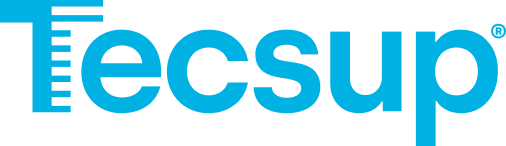

# DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN
## Carrera de Big Data y Ciencia de Datos
# TAREA 14: CONCEPTOS PRELIMINARES. MULTICLASIFICADORES

## Integrantes:
- Cora Salazar Joshua Jian
- Olortegui Perez Kevin Estiben

**CONFIGURACIÓN INICIAL**

In [ ]:
pip install ucimlrepo scikit-learn pandas matplotlib numpy -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
# Configuración de visualización
plt.rcParams.update({'font.size': 12})
np.set_printoptions(precision=4)

## a. Lea la data, asigne nombres para las columnas según su descripción y separe los datos en entrenamiento (80%) y prueba (20%), siendo la variable de clasificación la primera columna

In [ ]:
# Obtener dataset
print("\n>>> Paso 1: Cargando datos desde UCI Repository...")
wine = fetch_ucirepo(id=109)
X = wine.data.features
y = wine.data.targets
print(f"- Dataset cargado: {X.shape[0]} muestras, {X.shape[1]} características")


>>> Paso 1: Cargando datos desde UCI Repository...
- Dataset cargado: 178 muestras, 13 características


In [ ]:
# Asignar nombres descriptivos
print("\n>>> Paso 2: Asignando nombres a columnas...")
feature_names = [
    'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash',
    'Magnesium', 'Total_phenols', 'Flavanoids',
    'Nonflavanoid_phenols', 'Proanthocyanins',
    'Color_intensity', 'Hue', 'OD280_OD315', 'Proline'
]
X.columns = feature_names
y = y.rename(columns={'class': 'Wine_class'})
print("- Columnas renombradas:")
print(pd.concat([y.head(1), X.head(1)], axis=1).columns.tolist())


>>> Paso 2: Asignando nombres a columnas...
- Columnas renombradas:
['Wine_class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', 'OD280_OD315', 'Proline']


In [ ]:
# Dividir datos
print("\n>>> Paso 3: División entrenamiento (80%) - prueba (20%)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"- Conjunto entrenamiento: {X_train.shape[0]} muestras")
print(f"- Conjunto prueba: {X_test.shape[0]} muestras")


>>> Paso 3: División entrenamiento (80%) - prueba (20%)...
- Conjunto entrenamiento: 142 muestras
- Conjunto prueba: 36 muestras


In [ ]:
# Estandarizar características
print("\n>>> Paso 4: Estandarización de características...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("- Características estandarizadas (media=0, varianza=1)")


>>> Paso 4: Estandarización de características...
- Características estandarizadas (media=0, varianza=1)


## b. Entrene los modelos de regresión logística, árbol de decisión para clasificación y Suport Vector Machines para clasificación con los hiperparámetros adecuados. Además, halle la matriz de confusión para cada uno de estos.

In [ ]:
def entrenar_evaluar_modelo(modelo, nombre, X_train, y_train, X_test, y_test):
    print(f"\n>>> Entrenando {nombre}...")
    print(f"- Hiperparámetros: {modelo.get_params()}")
    modelo.fit(X_train, y_train.values.ravel())
    y_pred = modelo.predict(X_test)

    # Matriz de confusión gráfica
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.show()

    # Reporte de clasificación
    print(f"\nReporte de clasificación {nombre}:")
    print(classification_report(y_test, y_pred, digits=4))

    return modelo


--------------------------------------------------
 MODELO 1: REGRESIÓN LOGÍSTICA
--------------------------------------------------

>>> Entrenando Regresión Logística...
- Hiperparámetros: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'multinomial', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


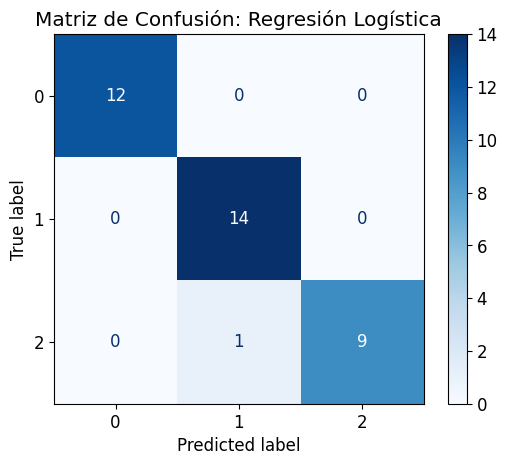


Reporte de clasificación Regresión Logística:
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000        12
           2     0.9333    1.0000    0.9655        14
           3     1.0000    0.9000    0.9474        10

    accuracy                         0.9722        36
   macro avg     0.9778    0.9667    0.9710        36
weighted avg     0.9741    0.9722    0.9720        36



In [ ]:
# 1. Regresión Logística
print("\n" + "-"*50)
print(" MODELO 1: REGRESIÓN LOGÍSTICA")
print("-"*50)
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial'
)
log_reg = entrenar_evaluar_modelo(log_reg, "Regresión Logística",
                                 X_train_scaled, y_train,
                                 X_test_scaled, y_test)


--------------------------------------------------
 MODELO 2: ÁRBOL DE DECISIÓN
--------------------------------------------------

>>> Entrenando Árbol de Decisión...
- Hiperparámetros: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


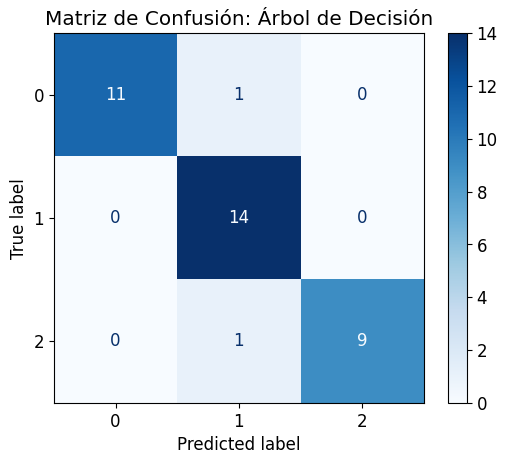


Reporte de clasificación Árbol de Decisión:
              precision    recall  f1-score   support

           1     1.0000    0.9167    0.9565        12
           2     0.8750    1.0000    0.9333        14
           3     1.0000    0.9000    0.9474        10

    accuracy                         0.9444        36
   macro avg     0.9583    0.9389    0.9457        36
weighted avg     0.9514    0.9444    0.9450        36



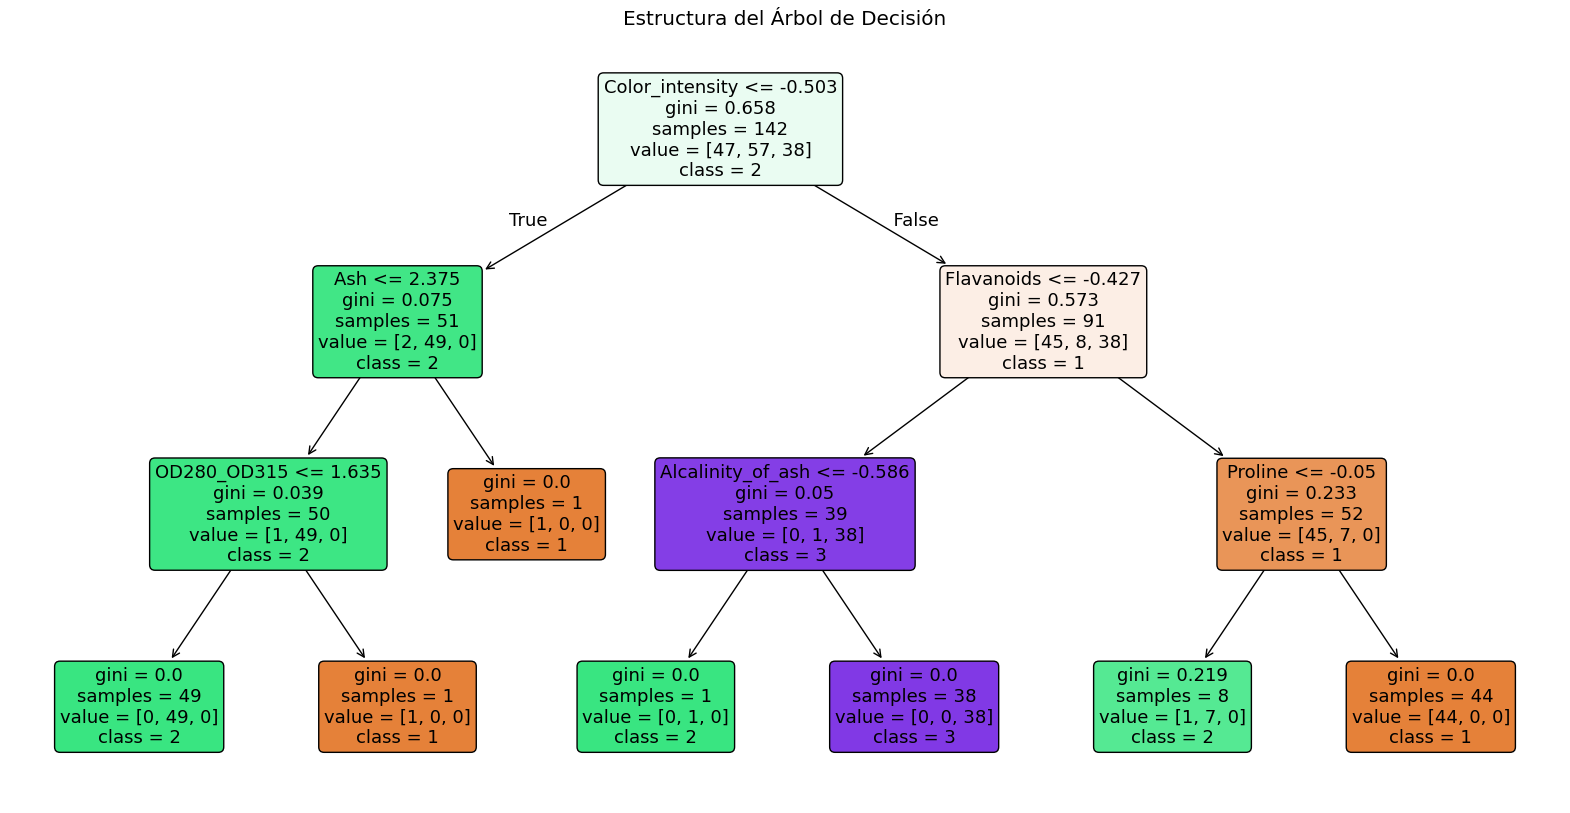

In [ ]:
# 2. Árbol de Decisión
print("\n" + "-"*50)
print(" MODELO 2: ÁRBOL DE DECISIÓN")
print("-"*50)
tree_clf = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
tree_clf = entrenar_evaluar_modelo(tree_clf, "Árbol de Decisión",
                                  X_train_scaled, y_train,
                                  X_test_scaled, y_test)

# Visualización del árbol (opcional para captura de pantalla)
plt.figure(figsize=(20,10))
plot_tree(tree_clf,
          feature_names=feature_names,
          class_names=['1', '2', '3'],
          filled=True,
          rounded=True)
plt.title("Estructura del Árbol de Decisión")
plt.show()


--------------------------------------------------
 MODELO 3: SUPPORT VECTOR MACHINE
--------------------------------------------------

>>> Entrenando Support Vector Machine...
- Hiperparámetros: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


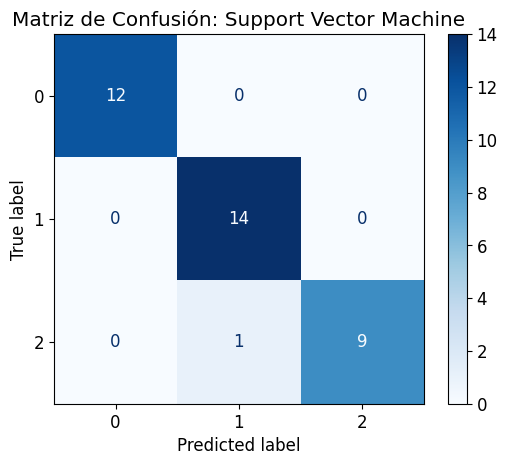


Reporte de clasificación Support Vector Machine:
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000        12
           2     0.9333    1.0000    0.9655        14
           3     1.0000    0.9000    0.9474        10

    accuracy                         0.9722        36
   macro avg     0.9778    0.9667    0.9710        36
weighted avg     0.9741    0.9722    0.9720        36



In [ ]:
# 3. Support Vector Machine
print("\n" + "-"*50)
print(" MODELO 3: SUPPORT VECTOR MACHINE")
print("-"*50)
svm_clf = SVC(
    C=1.0,
    kernel='rbf',
    probability=True,
    random_state=42
)
svm_clf = entrenar_evaluar_modelo(svm_clf, "Support Vector Machine",
                                 X_train_scaled, y_train,
                                 X_test_scaled, y_test)

## c. Realice un ensamblaje mediante el algoritmo voting utilizando los modelos de la parte b con los mismos hiperparámetros y halle su matriz de confusión. Indique cómo fueron obtenidas las clases de acuerdo al voting.

In [ ]:
print("\n>>> Creando Voting Classifier con los 3 modelos...")
voting_clf = VotingClassifier(
    estimators=[
        ('log_reg', log_reg),
        ('tree_clf', tree_clf),
        ('svm_clf', svm_clf)
    ],
    voting='soft'
)
print(f"- Tipo de voting: {voting_clf.voting}")
print("- Modelos incluidos:")
for name, model in voting_clf.estimators:
    print(f"  - {name} ({model.__class__.__name__})")

voting_clf.fit(X_train_scaled, y_train.values.ravel())
y_pred_voting = voting_clf.predict(X_test_scaled)


>>> Creando Voting Classifier con los 3 modelos...
- Tipo de voting: soft
- Modelos incluidos:
  - log_reg (LogisticRegression)
  - tree_clf (DecisionTreeClassifier)
  - svm_clf (SVC)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


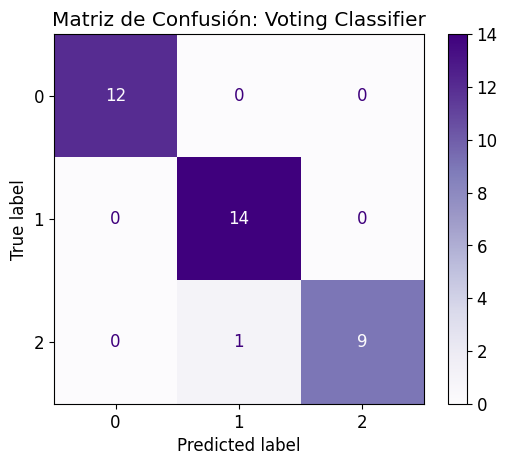

In [ ]:
# Matriz de confusión gráfica
cm_voting = confusion_matrix(y_test, y_pred_voting)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_voting)
disp.plot(cmap='Purples', values_format='d')
plt.title('Matriz de Confusión: Voting Classifier')
plt.show()

In [ ]:
# Reporte de clasificación
print("\nReporte de clasificación Voting Classifier:")
print(classification_report(y_test, y_pred_voting, digits=4))

# Explicación del mecanismo de voting
print("\n>>> Mecanismo de obtención de clases:")
print("Tipo: SOFT VOTING (votación probabilística)")
print("1. Cada modelo estima probabilidades para cada clase")
print("2. Para cada muestra, se promedian las probabilidades de todos los modelos")
print("3. Se asigna la clase con la mayor probabilidad promedio")

# Ejemplo concreto
print("\nEjemplo para la primera muestra del conjunto de prueba:")
sample_probs = voting_clf.predict_proba(X_test_scaled[:1])[0]
print(f"Probabilidades promedio: {sample_probs}")
predicted_class = np.argmax(sample_probs) + 1
print(f"Clase asignada: {predicted_class}")

# Verificación con modelos individuales
print("\nProbabilidades de modelos individuales para la misma muestra:")
for name, model in voting_clf.estimators:
    probs = model.predict_proba(X_test_scaled[:1])[0]
    print(f"- {name}: {probs} → Clase predicha: {np.argmax(probs) + 1}")


Reporte de clasificación Voting Classifier:
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000        12
           2     0.9333    1.0000    0.9655        14
           3     1.0000    0.9000    0.9474        10

    accuracy                         0.9722        36
   macro avg     0.9778    0.9667    0.9710        36
weighted avg     0.9741    0.9722    0.9720        36


>>> Mecanismo de obtención de clases:
Tipo: SOFT VOTING (votación probabilística)
1. Cada modelo estima probabilidades para cada clase
2. Para cada muestra, se promedian las probabilidades de todos los modelos
3. Se asigna la clase con la mayor probabilidad promedio

Ejemplo para la primera muestra del conjunto de prueba:
Probabilidades promedio: [0.9963 0.0015 0.0022]
Clase asignada: 1

Probabilidades de modelos individuales para la misma muestra:
- log_reg: [9.9967e-01 3.0662e-04 2.2579e-05] → Clase predicha: 1
- tree_clf: [1. 0. 0.] → Clase predicha: 1
- svm_clf: 

**Resultados Finales**

In [ ]:
print("\n\n" + "="*80)
print("RESUMEN DE RESULTADOS")
print("="*80)
print(f"- Precisión Regresión Logística: {log_reg.score(X_test_scaled, y_test):.4f}")
print(f"- Precisión Árbol Decisión: {tree_clf.score(X_test_scaled, y_test):.4f}")
print(f"- Precisión SVM: {svm_clf.score(X_test_scaled, y_test):.4f}")
print(f"- Precisión Voting Classifier: {voting_clf.score(X_test_scaled, y_test):.4f}")



RESUMEN DE RESULTADOS
- Precisión Regresión Logística: 0.9722
- Precisión Árbol Decisión: 0.9444
- Precisión SVM: 0.9722
- Precisión Voting Classifier: 0.9722
